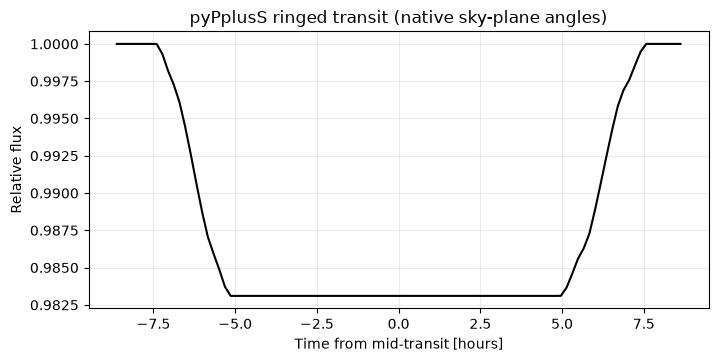

In [2]:
# PhotoRing Simulator (https://seap-udea.github.io/apps/photoring-simulator) → pyPplusS (Rein & Ofir 2019)
# Generated from the current photoring-simulator configuration.
# Uncomment in Colab if pyppluss is not installed yet:
# %pip install -q pyppluss matplotlib

import matplotlib.pyplot as plt
from pyppluss.segment_models import LC_ringed
import numpy as np
if not hasattr(np, "NaN"):np.NaN = np.nan

# Constants
deg = np.pi / 180 # factor from degrees to radians
rad = 1 / deg

# System parameters
p = 0.084 # planet radius [R*]
fi = 1.58 # inner ring [Rp]
fe = 2.35 # outer ring [Rp]
tilt = 25.0*deg # sky-plane position angle / tilt
ir = 55.0*deg # sky-plane inclination (0=face-on, 90=edge-on)
b  = 0.25 # impact parameter [R*]
alpha = 0.37 # normal ring transmission exp(-tau_normal)
mstar = 1.0 # M* [M_sun]
rstar = 1.0 # R* [R_sun]
mpjup = 0.3 # Mp [Mjup]
porb= 365.25 # Porb [days]
a_rs= 215.0 # a/R*

# Derivative properties
iorb = np.arccos(b/a_rs)
vorb = 2*np.pi*a_rs*np.sin(iorb) / (porb * 24)

# Light curve parameters
ts_ppp = np.linspace(-8.62, 8.62, 100) # in hours
xs = vorb * ts_ppp
ones = np.ones_like(xs)
ys = b*ones

# Parameters in the units of the package
rps = p*ones
rins = p*fi*ones
routs = p*fe*ones
opacity = 1.0 - alpha ** (1.0 / np.cos(ir))

# Light curve
flux_pp = LC_ringed(
    rps, rins, routs, xs, ys,
    ir, tilt, opacity,
    0.0, 0.0, 0.0, 0.0
)

# Plot
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ts_ppp, flux_pp, color="k")
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Relative flux")
ax.set_title("pyPplusS ringed transit (native sky-plane angles)")
ax.grid(True, alpha=0.25)
plt.show()